In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

In [3]:
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [5]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [6]:
nav_df = nav_df.sort_values(["amfi_code", "date"])

In [7]:
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

In [8]:
nav_df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


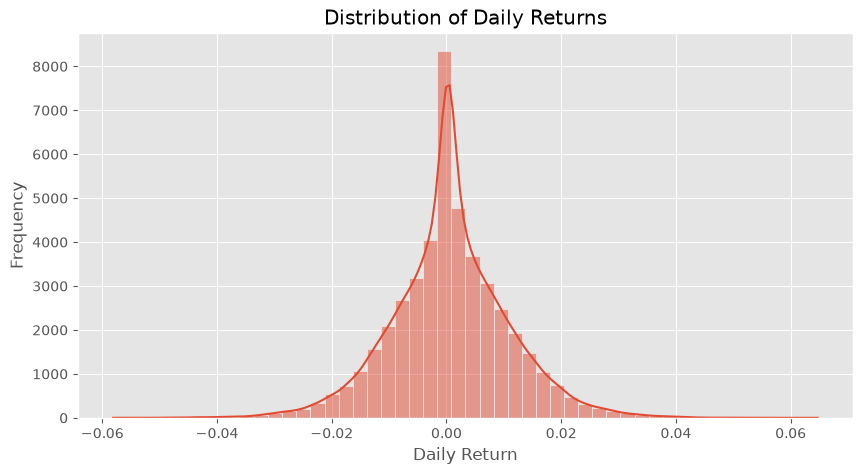

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav_df["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [10]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [11]:
cagr_results = []

In [12]:
for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[nav_df["amfi_code"] == fund].sort_values("date")

    latest_nav = fund_data.iloc[-1]["nav"]

    cagr_row = {
        "amfi_code": fund
    }

    for years in [1, 3, 5]:

        trading_days = years * 252

        if len(fund_data) > trading_days:

            old_nav = fund_data.iloc[-trading_days]["nav"]

            cagr = calculate_cagr(old_nav, latest_nav, years)

            cagr_row[f"CAGR_{years}Y"] = cagr

        else:

            cagr_row[f"CAGR_{years}Y"] = np.nan

    cagr_results.append(cagr_row)

In [13]:
cagr_df = pd.DataFrame(cagr_results)

In [14]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


In [15]:
cagr_df = cagr_df.sort_values(
    by="CAGR_3Y",
    ascending=False
)

In [16]:
cagr_df.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,0.309182,0.360660,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
34,148567,0.145807,0.312786,NaN
25,120505,0.303534,0.302065,NaN
24,120504,0.115007,0.283698,NaN
21,119598,0.845322,0.278144,NaN
19,119551,0.488839,0.277274,NaN
8,102887,0.127279,0.256630,NaN
30,120843,0.284811,0.256619,NaN


In [17]:
risk_free_rate = 0.065

In [18]:

sharpe_results = []


In [19]:
for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    if len(fund_returns) == 0:
        continue

    annual_return = fund_returns.mean() * 252
    annual_volatility = fund_returns.std() * np.sqrt(252)

    sharpe = (annual_return - risk_free_rate) / annual_volatility

    sharpe_results.append({
        "amfi_code": fund,
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe
    })

In [20]:
sharpe_df = pd.DataFrame(sharpe_results)

In [21]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

In [22]:
sharpe_df.head(10)

,amfi_code,Annual Return,Annual Volatility,Sharpe Ratio
34,148567,0.270566,0.141937,1.448291
30,120843,0.272602,0.158870,1.306744
36,148569,0.283262,0.176740,1.234930
19,119551,0.231033,0.137414,1.208267
25,120505,0.292653,0.192909,1.180101
38,149323,0.265908,0.177462,1.132122
2,100033,0.272111,0.189367,1.093699
9,118632,0.218037,0.141484,1.081659
3,101206,0.214647,0.145682,1.027213
24,120504,0.212448,0.143638,1.026524


C:\Users\parik\AppData\Local\Temp\ipykernel_20560\999889317.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


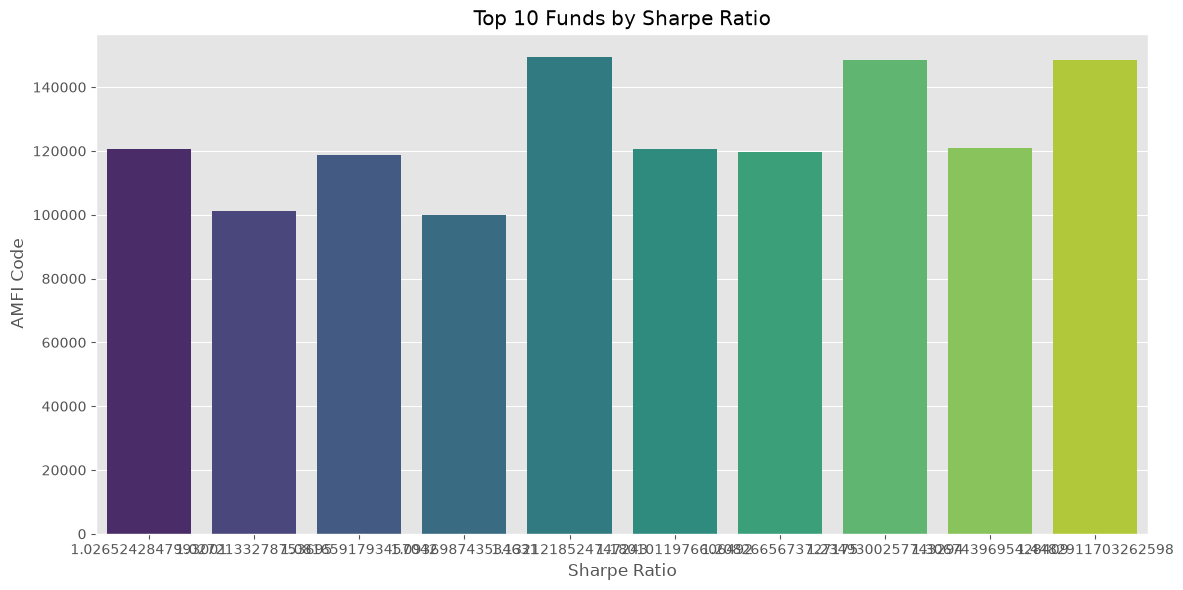

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sharpe_df.head(10),
    x="Sharpe Ratio",
    y="amfi_code",
    palette="viridis"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("AMFI Code")

plt.tight_layout()
plt.show()

C:\Users\parik\AppData\Local\Temp\ipykernel_20560\999889317.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


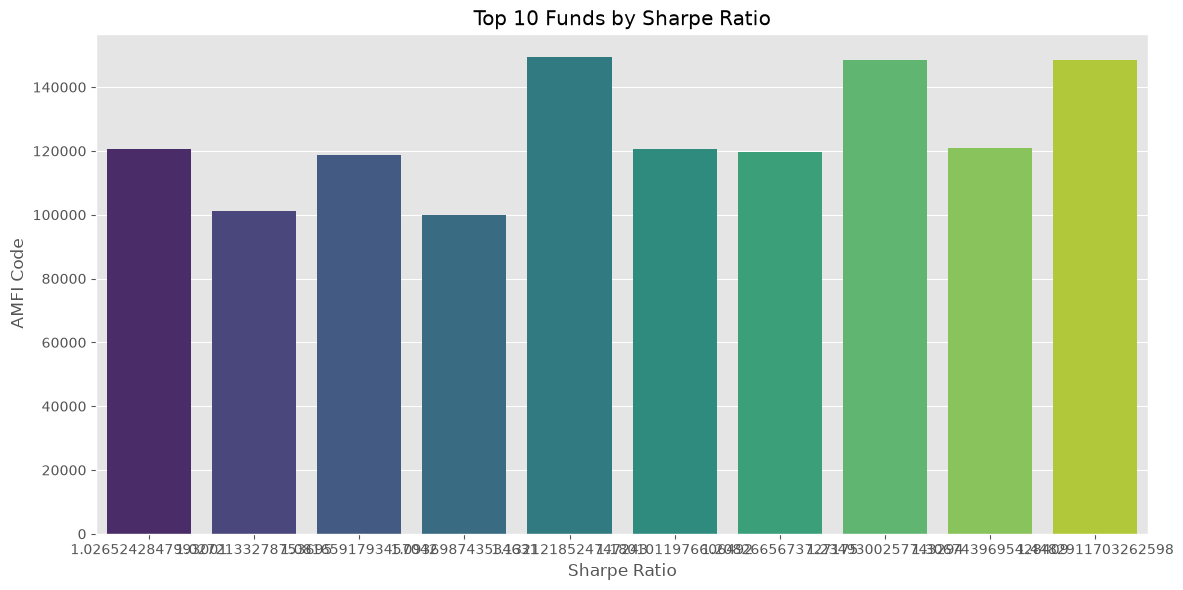

In [24]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sharpe_df.head(10),
    x="Sharpe Ratio",
    y="amfi_code",
    palette="viridis"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("AMFI Code")

plt.tight_layout()
plt.show()

In [25]:
for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    if len(fund_returns) == 0:
        continue

    annual_return = fund_returns.mean() * 252

    downside_returns = fund_returns[fund_returns < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (annual_return - risk_free_rate) / downside_std

    sortino_results.append({
        "amfi_code": fund,
        "Annual Return": annual_return,
        "Downside Risk": downside_std,
        "Sortino Ratio": sortino
    })

NameError: name 'sortino_results' is not defined

In [26]:
sortino_results = []

In [27]:
sortino_df = pd.DataFrame(sortino_results)

In [28]:
sortino_df = sortino_df.sort_values(
    by="Sortino Ratio",
    ascending=False
)

KeyError: 'Sortino Ratio'

In [29]:
sortino_df.columns

RangeIndex(start=0, stop=0, step=1)

In [30]:
len(sortino_results)

0

In [31]:
risk_free_rate

0.065

In [32]:
nav_df["daily_return"].isna().sum()

np.int64(40)

In [33]:
len(sortino_results)

0

In [34]:
fund = nav_df["amfi_code"].unique()[0]

fund_returns = nav_df[
    nav_df["amfi_code"] == fund
]["daily_return"].dropna()

print("Fund:", fund)
print("Number of returns:", len(fund_returns))

downside_returns = fund_returns[fund_returns < 0]

print("Negative returns:", len(downside_returns))

print("Std:", downside_returns.std())

Fund: 100016
Number of returns: 1149
Negative returns: 579
Std: 0.005260815192179734


In [35]:
sortino_results = []

In [36]:
for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df.loc[
        nav_df["amfi_code"] == fund, "daily_return"
    ].dropna()

    annual_return = fund_returns.mean() * 252

    downside_returns = fund_returns[fund_returns < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    sortino_ratio = (annual_return - risk_free_rate) / downside_std

    sortino_results.append({
        "amfi_code": fund,
        "Annual Return": annual_return,
        "Downside Risk": downside_std,
        "Sortino Ratio": sortino_ratio
    })

In [37]:
len(sortino_results)

40

In [38]:
sortino_df = pd.DataFrame(sortino_results)
sortino_df.head()

,amfi_code,Annual Return,Downside Risk,Sortino Ratio
0,100016,0.035683,0.083513,-0.351047
1,100025,0.042854,0.023514,-0.941821
2,100033,0.272111,0.113229,1.829134
3,101206,0.214647,0.083157,1.799563
4,101207,0.106962,0.151683,0.276644


In [39]:
sortino_df = sortino_df.sort_values(
    by="Sortino Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Annual Return,Downside Risk,Sortino Ratio
34,148567,0.270566,0.086168,2.385644
30,120843,0.272602,0.087806,2.364320
36,148569,0.283262,0.101663,2.146914
19,119551,0.231033,0.077576,2.140267
25,120505,0.292653,0.112180,2.029353
38,149323,0.265908,0.107145,1.875101
9,118632,0.218037,0.082717,1.850133
2,100033,0.272111,0.113229,1.829134
24,120504,0.212448,0.081675,1.805294
3,101206,0.214647,0.083157,1.799563


The Sortino Ratio ranks funds based on returns adjusted for downside risk. Funds with higher Sortino Ratios generated better returns while experiencing lower downside volatility, indicating stronger performance during adverse market conditions.

In [40]:
import os

files = os.listdir("../data/processed")
files

['01_fund_master_cleaned.csv',
 '02_nav_history_cleaned.csv',
 '03_aum_by_fund_house_cleaned.csv',
 '04_monthly_sip_inflows_cleaned.csv',
 '05_category_inflows_cleaned.csv',
 '06_industry_folio_count_cleaned.csv',
 '07_scheme_performance_cleaned.csv',
 '08_investor_transactions_cleaned.csv',
 '09_portfolio_holdings_cleaned.csv',
 '10_benchmark_indices_cleaned.csv']

In [41]:
benchmark_df = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

In [42]:
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [43]:
benchmark_df.columns.tolist()

['date', 'index_name', 'close_value']

In [44]:
benchmark_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


In [45]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

In [46]:
benchmark_df["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [47]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "Nifty 100"
].copy()

nifty100 = nifty100.sort_values("date")

In [48]:
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [49]:
test_fund = nav_df[
    nav_df["amfi_code"] == nav_df["amfi_code"].unique()[0]
].copy()

merged = pd.merge(
    test_fund,
    nifty100,
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,index_name,close_value,benchmark_return


In [50]:
slope, intercept, r_value, p_value, std_err = linregress(
    merged["benchmark_return"].dropna(),
    merged["daily_return"].dropna()
)

alpha = intercept * 252
beta = slope

print("Alpha:", alpha)
print("Beta:", beta)

Alpha: nan
Beta: nan


C:\Users\parik\AppData\Local\Temp\ipykernel_20560\2541673047.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = linregress(


In [51]:
benchmark_df["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [52]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

In [53]:
nifty100 = nifty100.sort_values("date")
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [54]:
print("Fund rows:", len(test_fund))
print("Benchmark rows:", len(nifty100))
print("Merged rows:", len(merged))

Fund rows: 1150
Benchmark rows: 1150
Merged rows: 0


In [55]:
print(test_fund["date"].head())

0   2022-01-03
1   2022-01-04
2   2022-01-05
3   2022-01-06
4   2022-01-07
Name: date, dtype: datetime64[us]


In [56]:
print(nifty100["date"].head())

1150   2022-01-03
1151   2022-01-04
1152   2022-01-05
1153   2022-01-06
1154   2022-01-07
Name: date, dtype: datetime64[us]


In [57]:
print("Fund:")
print(test_fund["date"].min(), test_fund["date"].max())

print("Benchmark:")
print(nifty100["date"].min(), nifty100["date"].max())

Fund:
2022-01-03 00:00:00 2026-05-29 00:00:00
Benchmark:
2022-01-03 00:00:00 2026-05-29 00:00:00


In [58]:
print(test_fund["date"].dtype)
print(nifty100["date"].dtype)

datetime64[us]
datetime64[us]


In [59]:
print(test_fund.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [60]:
print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [61]:
print(test_fund["date"].head(10).tolist())

[Timestamp('2022-01-03 00:00:00'), Timestamp('2022-01-04 00:00:00'), Timestamp('2022-01-05 00:00:00'), Timestamp('2022-01-06 00:00:00'), Timestamp('2022-01-07 00:00:00'), Timestamp('2022-01-10 00:00:00'), Timestamp('2022-01-11 00:00:00'), Timestamp('2022-01-12 00:00:00'), Timestamp('2022-01-13 00:00:00'), Timestamp('2022-01-14 00:00:00')]


In [62]:
print(nifty100["date"].head(10).tolist())

[Timestamp('2022-01-03 00:00:00'), Timestamp('2022-01-04 00:00:00'), Timestamp('2022-01-05 00:00:00'), Timestamp('2022-01-06 00:00:00'), Timestamp('2022-01-07 00:00:00'), Timestamp('2022-01-10 00:00:00'), Timestamp('2022-01-11 00:00:00'), Timestamp('2022-01-12 00:00:00'), Timestamp('2022-01-13 00:00:00'), Timestamp('2022-01-14 00:00:00')]


In [63]:
common_dates = set(test_fund["date"]).intersection(set(nifty100["date"]))

print("Common dates:", len(common_dates))

Common dates: 1150


In [64]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [65]:
test_fund = nav_df[
    nav_df["amfi_code"] == nav_df["amfi_code"].unique()[0]
].copy()

test_fund["date"] = pd.to_datetime(test_fund["date"])

In [66]:
merged = pd.merge(
    test_fund[["date", "daily_return"]],
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

In [67]:
print(merged.shape)
merged.head()

(1150, 3)


,date,daily_return,benchmark_return
0,2022-01-03,NaN,NaN
1,2022-01-04,-0.010306,-0.013540
2,2022-01-05,0.012865,0.004003
3,2022-01-06,-0.011377,-0.002935
4,2022-01-07,-0.001210,0.006150


In [68]:
merged = merged.dropna()

print(merged.shape)

(1149, 3)


In [69]:
slope, intercept, r_value, p_value, std_err = linregress(
    merged["benchmark_return"],
    merged["daily_return"]
)

alpha = intercept * 252
beta = slope

print("Alpha:", alpha)
print("Beta:", beta)

Alpha: 0.03747580763443282
Beta: -0.05826843143880895


In [70]:
alpha_beta_results = []

In [71]:
for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[
        nav_df["amfi_code"] == fund
    ][["date", "daily_return"]].copy()

    fund_df["date"] = pd.to_datetime(fund_df["date"])

    merged = pd.merge(
        fund_df,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": fund,
        "Alpha": intercept * 252,
        "Beta": slope,
        "R_squared": r_value**2
    })

In [72]:
alpha_beta_df = pd.DataFrame(alpha_beta_results)

In [73]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [74]:
alpha_beta_df = alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
)

alpha_beta_df.head(10)

,amfi_code,Alpha,Beta,R_squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04
2,100033,0.271954,0.005104,1.206652e-05
34,148567,0.269838,0.023684,4.625437e-04
38,149323,0.265986,-0.002523,3.357978e-06
16,119094,0.260767,-0.066265,1.936879e-03
19,119551,0.232010,-0.031751,8.869789e-04


In [75]:
alpha_beta_df.to_csv("../reports/alpha_beta.csv", index=False)

In [76]:
drawdown_results = []

In [77]:
for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    fund_df = fund_df.sort_values("date")

    # Running maximum NAV
    fund_df["running_max"] = fund_df["nav"].cummax()

    # Drawdown
    fund_df["drawdown"] = (
        fund_df["nav"] / fund_df["running_max"]
    ) - 1

    # Worst drawdown
    max_dd = fund_df["drawdown"].min()

    # Date when it happened
    worst_row = fund_df.loc[
        fund_df["drawdown"].idxmin()
    ]

    drawdown_results.append({
        "amfi_code": fund,
        "Maximum Drawdown": max_dd,
        "Worst Date": worst_row["date"]
    })

In [78]:
drawdown_df = pd.DataFrame(drawdown_results)

In [79]:
drawdown_df = drawdown_df.sort_values(
    by="Maximum Drawdown"
)

drawdown_df.head(10)

,amfi_code,Maximum Drawdown,Worst Date
22,119599,-0.525742,2025-10-28
17,119095,-0.516778,2026-05-11
4,101207,-0.354469,2026-05-11
39,149324,-0.311719,2025-01-03
21,119598,-0.287060,2025-05-14
7,102886,-0.280011,2026-04-27
0,100016,-0.247344,2022-09-15
29,120842,-0.240035,2024-10-17
11,118634,-0.233449,2026-02-20
15,119093,-0.217514,2023-05-22


C:\Users\parik\AppData\Local\Temp\ipykernel_20560\787685941.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


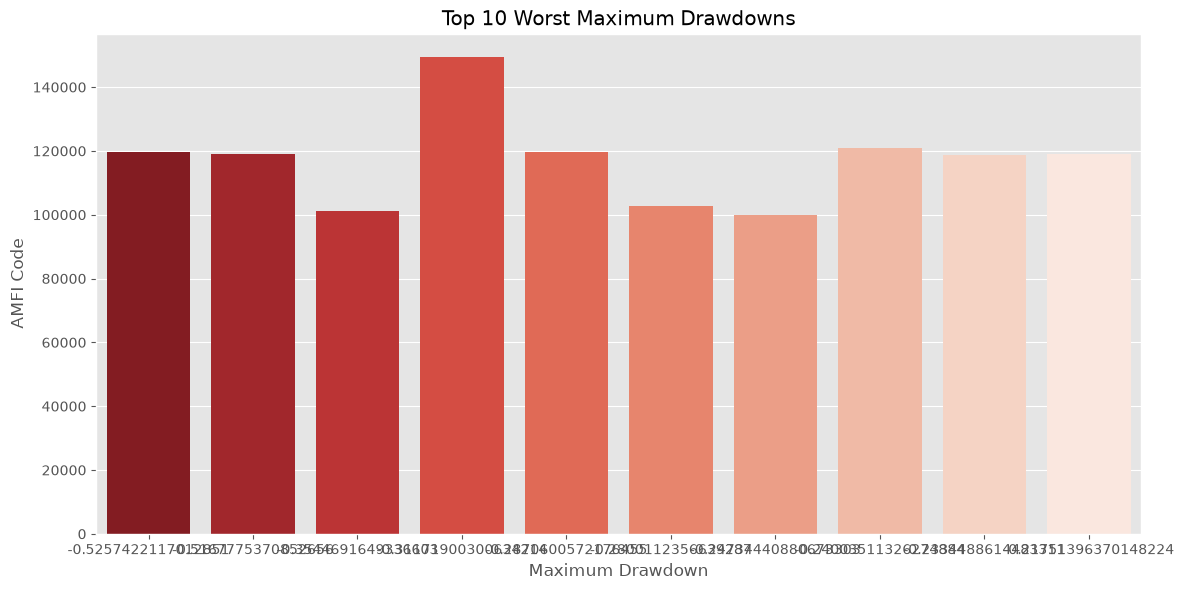

In [80]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=drawdown_df.head(10),
    x="Maximum Drawdown",
    y="amfi_code",
    palette="Reds_r"
)

plt.title("Top 10 Worst Maximum Drawdowns")
plt.xlabel("Maximum Drawdown")
plt.ylabel("AMFI Code")

plt.tight_layout()
plt.show()

In [81]:
drawdown_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

Observation

Maximum Drawdown measures the largest decline in a fund's NAV from its historical peak. Funds with smaller drawdowns demonstrated better resilience during market downturns, while larger drawdowns indicate higher downside risk.

In [82]:
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

In [83]:
fund_master.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [84]:
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

In [85]:
expense_df = fund_master[["amfi_code", "expense_ratio"]].copy()

KeyError: "['expense_ratio'] not in index"

In [86]:
fund_master.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [87]:
expense_df = fund_master[["amfi_code", "expense_ratio_pct"]].copy()

In [88]:
scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

NameError: name 'scorecard' is not defined

In [89]:
cagr_df.columns.tolist()

['amfi_code', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y']

In [90]:
sharpe_df.columns.tolist()

['amfi_code', 'Annual Return', 'Annual Volatility', 'Sharpe Ratio']

In [91]:
alpha_beta_df.columns.tolist()

['amfi_code', 'Alpha', 'Beta', 'R_squared']

In [92]:
drawdown_df.columns.tolist()

['amfi_code', 'Maximum Drawdown', 'Worst Date']

In [93]:
fund_master.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [94]:
expense_df = fund_master[
    ["amfi_code", "expense_ratio_pct"]
].copy()

In [95]:
scorecard = cagr_df.merge(
    sharpe_df[["amfi_code", "Sharpe Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Maximum Drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    expense_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe Ratio,Alpha,Maximum Drawdown,expense_ratio_pct
0,119094,0.309182,0.360660,NaN,0.998231,0.260767,-0.209609,1.38
1,100033,0.477346,0.336292,NaN,1.093699,0.271954,-0.162172,1.38
2,101206,0.450939,0.325286,NaN,1.027213,0.213998,-0.112916,1.60
3,148567,0.145807,0.312786,NaN,1.448291,0.269838,-0.112657,1.46
4,120505,0.303534,0.302065,NaN,1.180101,0.292636,-0.181885,1.36


In [96]:
scorecard["CAGR Rank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["Alpha Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown Rank"] = scorecard["Maximum Drawdown"].rank(ascending=False)

In [97]:
scorecard["Weighted Score"] = (
      0.30 * scorecard["CAGR Rank"]
    + 0.25 * scorecard["Sharpe Rank"]
    + 0.20 * scorecard["Alpha Rank"]
    + 0.15 * scorecard["Expense Rank"]
    + 0.10 * scorecard["Drawdown Rank"]
)

In [98]:
scorecard["Fund Score"] = (
    (scorecard["Weighted Score"].max() - scorecard["Weighted Score"])
    /
    (scorecard["Weighted Score"].max() - scorecard["Weighted Score"].min())
) * 100

In [99]:
scorecard = scorecard.sort_values(
    by="Fund Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe Ratio,Alpha,Maximum Drawdown,expense_ratio_pct,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Weighted Score,Fund Score
3,148567,0.145807,0.312786,NaN,1.448291,0.269838,-0.112657,1.46,4.0,1.0,7.0,23.0,8.0,7.100,100.000000
1,100033,0.477346,0.336292,NaN,1.093699,0.271954,-0.162172,1.38,2.0,7.0,6.0,17.0,20.0,8.100,96.488147
4,120505,0.303534,0.302065,NaN,1.180101,0.292636,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,8.100,96.488147
9,120843,0.284811,0.256619,NaN,1.306744,0.273305,-0.129740,1.45,10.0,2.0,5.0,22.0,13.0,9.100,92.976295
5,120504,0.115007,0.283698,NaN,1.026524,0.211948,-0.125883,0.80,6.0,10.0,13.0,12.0,12.0,9.900,90.166813
0,119094,0.309182,0.360660,NaN,0.998231,0.260767,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,10.200,89.113257
7,119551,0.488839,0.277274,NaN,1.208267,0.232010,-0.150124,1.54,8.0,4.0,10.0,30.5,17.0,11.675,83.933275
2,101206,0.450939,0.325286,NaN,1.027213,0.213998,-0.112916,1.60,3.0,9.0,12.0,36.5,9.0,11.925,83.055312
6,119598,0.845322,0.278144,NaN,0.945308,0.303370,-0.287060,1.43,7.0,14.0,1.0,21.0,36.0,12.550,80.860404
12,148569,0.444657,0.233171,NaN,1.234930,0.282704,-0.163967,1.60,13.0,3.0,4.0,36.5,21.0,13.025,79.192274


In [100]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

Observation

The composite Fund Score combines return, risk, alpha generation, expense ratio, and downside protection into a single performance metric. Higher-scoring funds demonstrate a balanced combination of strong returns, efficient risk management, lower expenses, and resilience during market downturns.

In [101]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

nifty50 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

In [102]:
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [103]:
top5_funds = scorecard.head(5)["amfi_code"].tolist()

top5_funds

[148567, 100033, 120505, 120843, 120504]

In [104]:
tracking_results = []

In [105]:
for fund in top5_funds:

    fund_df = nav_df[
        nav_df["amfi_code"] == fund
    ][["date", "daily_return"]].copy()

    merged = pd.merge(
        fund_df,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": fund,
        "Tracking Error": tracking_error
    })

In [106]:
tracking_df = pd.DataFrame(tracking_results)

tracking_df

,amfi_code,Tracking Error
0,148567,0.189664
1,100033,0.228699
2,120505,0.231968
3,120843,0.206425
4,120504,0.191587


In [107]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

In [108]:
best_fund = top5_funds[0]

best_df = nav_df[
    nav_df["amfi_code"] == best_fund
].copy()

In [109]:
comparison = pd.merge(
    best_df[["date", "nav"]],
    nifty100[["date", "close_value"]],
    on="date"
)

In [110]:
comparison.columns = [
    "Date",
    "Fund NAV",
    "NIFTY100"
]

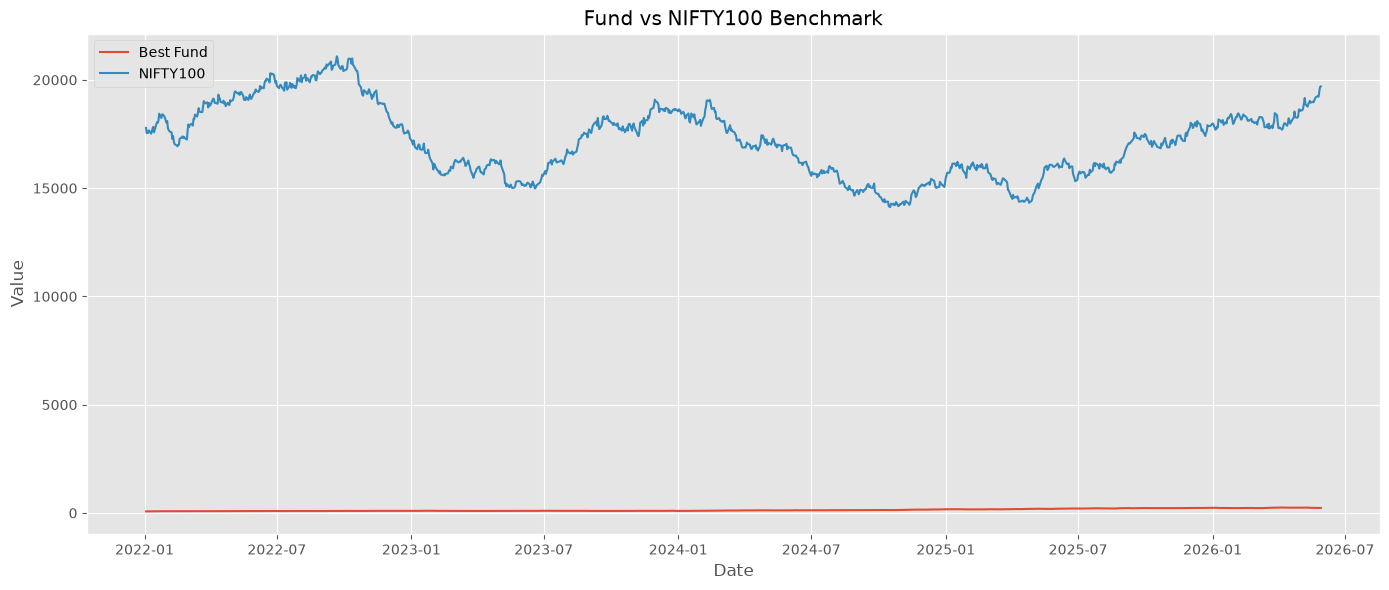

In [111]:
plt.figure(figsize=(14,6))

plt.plot(
    comparison["Date"],
    comparison["Fund NAV"],
    label="Best Fund"
)

plt.plot(
    comparison["Date"],
    comparison["NIFTY100"],
    label="NIFTY100"
)

plt.legend()

plt.title("Fund vs NIFTY100 Benchmark")

plt.xlabel("Date")

plt.ylabel("Value")

plt.tight_layout()

plt.show()

Observation

The benchmark comparison illustrates how the top-performing mutual fund tracked against the NIFTY100 index over time. Tracking Error quantifies the deviation between the fund's returns and benchmark returns, with lower values indicating closer benchmark replication.